<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 2</b><br>

  Hello Samiul, congratulations on submitting your project!<br>

  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br>

  <b>What you did well:</b><br>
  ✅ You loaded and inspected all datasets and converted date columns to datetime, which fixes a common source of errors.<br>
  ✅ You enriched the users table with useful features and aggregated usage to the user-month level before revenue calculation, which supports the later analysis.<br>
  ✅ You addressed the required corrections related to the monthly call duration statistics, the hypothesis testing setup, and the NY/NJ region grouping.<br>
  ✅ You added clearer statistical testing steps, including the necessary hypothesis statements, significance level, cleaned revenue samples, and group-size checks.<br>
  ✅ Overall, the main issues from the previous review have been addressed, and the project now meets the requirements for approval.<br>

  <b>Project Status:</b><br>
  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
    <b>Approved ✅</b>
  </div>

</div>


<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The bracketed template guidance text is still present in this section. Consider removing those bracketed notes before submitting and replacing them with a short project purpose/plan written in your own words.

</div>


## Initialization

In [1]:
# Loading all the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import math
from matplotlib import pyplot as plt
from scipy import stats as st

## Load data

In [2]:
# Load the data files into different DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')

In [3]:
internet = pd.read_csv('/datasets/megaline_internet.csv')

In [4]:
messages = pd.read_csv('/datasets/megaline_messages.csv')

In [5]:
plans = pd.read_csv('/datasets/megaline_plans.csv')

In [6]:
users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare the data

[The data for this project is split into several tables. Explore each one to get an initial understanding of the data. Do necessary corrections to each table if necessary.]

## Plans

In [7]:
# Print the general/summary information about the plans' DataFrame
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [8]:
# Print a sample of data for plans
plans.sample()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf


The plan DF contain 2 rows and 8 columns. One row per plan which is surf and ultimate. There are no missing values across any column, so no imputation is needed. Data types look generally appropriate: integer columns for whole-number quantities (messages, minutes, MB), floats for per-unit prices, and object for the plan name. No immediate dtype issues stand out. Key issues is column name mismatch: The data dictionary specifies the monthly charge column should be named usd_monthly_fee, but the actual DataFrame has it named usd_monthly_pay. This discrepancy needs to be corrected to ensure consistency with the rest of the project.Column ordering: plan_name appears as the last column, but logically it makes more sense as the first column (as a primary identifier).

## Fix data

In [9]:
plans.columns = plans.columns.str.replace('usd_monthly_pay', 'usd_monthly_fee')
plans = plans[['plan_name', 'usd_monthly_fee', 'minutes_included', 'messages_included', 'mb_per_month_included',
              'usd_per_minute', 'usd_per_message', 'usd_per_gb']]
plans = plans.rename(columns = {'plan_name' : 'plan'})

## Enrich data

In [10]:
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024

## Users

In [11]:
# Print the general/summary information about the users' DataFrame
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [12]:
# Print a sample of data for users
users.sample()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN


(1) Missing values in churn_date — only 34 non-null out of 500
This means 466 users are still active (no churn date). This is expected behavior, not a data error — as discussed earlier, NaN here means the user hasn't left yet. The last_date column correctly handles this by filling with today's date.
(2) Date columns stored as object instead of datetime
Three columns — reg_date, churn_date — are all object dtype. They should be datetime64 for proper date arithmetic and filtering. (3) last_date contains a full timestamp instead of just a date (4) plan stored as object
could be converted to category since there are only two possible values (surf/ultimate)

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

In your users table review, you mention a “last_date” column as if it exists in the original dataset, but it’s an engineered feature you create later. Consider separating “original data issues” from “features added during enrichment” to keep the narrative clear.

</div>


### Fix Data

In [13]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
users['plan'] = users['plan'].astype('category')

### Enrich Data

In [14]:
users['last_date'] = users['churn_date'].fillna(pd.Timestamp('today'))
users['tenure_days'] = (pd.to_datetime(users['last_date']) - pd.to_datetime(users['reg_date'])).dt.days
users['reg_month'] = pd.to_datetime(users['reg_date']).dt.month
users['reg_year'] = pd.to_datetime(users['reg_date']).dt.year
users['is_active'] = users['churn_date'].isna()
bins = [0, 30, 45, 60, 100]
labels = ['young', 'middle-aged', 'senior', 'elderly']
users['age_group'] = pd.cut(users['age'], bins=bins, labels=labels)
users['tenure_months'] = (users['tenure_days'] / 30).astype(int)

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice job converting the date columns to datetime and enriching the users table with useful features (e.g., active flag, tenure, registration month/year). These can support more detailed segmentation later.

</div>


## Calls

In [15]:
# Print the general/summary information about the calls' DataFrame
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [16]:
# Print a sample of data for calls
calls.sample()

,id,user_id,call_date,duration
55644,1199_289,1199,2018-12-20,6.55


(1) call_date stored as object should be converted to datetime64 for proper time-based filtering and grouping. (2) duration is float64 — needs rounding up. Call duration of 5.13 minutes is a decimal, but telecom billing typically rounds up to the nearest whole minute. A 5.13-minute call would be billed as 6 minutes. (3) id stored as object. The sample shows a string format like 1472_521 — this is a composite ID combining user and call identifiers. It's not purely numeric, so object is acceptable, but worth noting it can't be used for numeric operations.

### Fix data

In [17]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['duration'] = calls['duration'].apply(math.ceil)

### Enrich data

In [18]:
calls['call_month'] = pd.to_datetime(calls['call_date']).dt.month
calls['day_of_week'] = pd.to_datetime(calls['call_date']).dt.day_name()
calls['duration_category'] = pd.cut(calls['duration'], bins = [0, 2, 10, float('inf')], labels = ['short', 'medium', 'long'])
calls['call_year'] = pd.to_datetime(calls['call_date']).dt.year
calls['is_zero_duration'] = calls['duration'] == 0

## Messages

In [19]:
# Print the general/summary information about the messages' DataFrame
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [20]:
# Print a sample of data for messages
messages.sample()

,id,user_id,message_date
19728,1126_538,1126,2018-07-20


(1) message_date stored as object. Same issue as call_date in the calls DataFrame, it needs converting to datetime64. (2) id is a composite string. The sample shows 1242_27 is the same pattern as in calls. It's not numeric, so object is technically fine, but it cannot be used for any numeric operations but it is worth documenting. (3) No duration equivalent — simpler than calls. Unlike calls, each row simply represents one message sent, there's no quantity or size column to worry about rounding or categorizing. Billing just counts the number of messages per month, which makes aggregation straightforward.

### Fix data

In [21]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

### Enrich data

In [22]:
messages['message_month'] = pd.to_datetime(messages['message_date']).dt.month
messages['message_year'] = pd.to_datetime(messages['message_date']).dt.year
messages['day_of_week'] = pd.to_datetime(messages['message_date']).dt.day_name()

## Internet

In [23]:
# Print the general/summary information about the internet DataFrame
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [24]:
# Print a sample of data for the internet traffic
internet.sample()

,id,user_id,session_date,mb_used
11728,1057_68,1057,2018-09-27,785.04


(1)  session_date stored as object — needs datetime conversion. (2) mb_used is float64 — needs rounding up to GB
This is the most important business logic issue here. Two things need to happen: (a) First, round MB up to whole MB (same ceiling logic as call duration) (b) Then, convert to GB for billing (since plans use usd_per_gb). (3) id is a composite string. Same 1408_470 pattern as calls and messages — object dtype is acceptable but non-numeric.

### Fix data

In [25]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet['gb_used'] = internet['mb_used'] / 1024

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Internet billing is based on rounding up the *total monthly* usage to whole GB. Converting MB→GB per session is fine for exploration, but be careful not to treat that as billed usage. Consider aggregating monthly total MB per user first, then applying the ceiling when converting to billed GB (and treating months with no sessions as 0 usage).

</div>


### Enrich data

In [26]:
internet['internet_month'] = pd.to_datetime(internet['session_date']).dt.month
internet['internet_year'] = pd.to_datetime(internet['session_date']).dt.year
internet['day_of_week'] =pd.to_datetime(internet['session_date']).dt.day_name()
internet['usage_category'] = pd.cut(internet['mb_used'], bins = [0, 50, 500, float('inf')], labels = ['light', 'medium', 'heavy'])
internet['is_heavy_session'] = internet['mb_used'] > 1024

## Study plan conditions

In [27]:
# Print out the plan conditions and make sure they are clear for you
print(plans)

       plan  usd_monthly_fee  minutes_included  messages_included  \
0      surf               20               500                 50   
1  ultimate               70              3000               1000   

   mb_per_month_included  usd_per_minute  usd_per_message  usd_per_gb  \
0                  15360            0.03             0.03          10   
1                  30720            0.01             0.01           7   

   gb_per_month_included  
0                   15.0  
1                   30.0  


## Aggregate data per user

In [28]:
# Calculate the number of calls made by each user per month. Save the result.
calls_per_user_month = calls.groupby(['user_id', 'call_month']).agg(
    call_count = ('id', 'count'), total_minutes = ('duration', 'sum')).reset_index()
calls_per_user_month = calls_per_user_month.rename(columns = {'call_month' : 'month'})
calls_per_user_month.head(10)

,user_id,month,call_count,total_minutes
0,1000,12,16,124
1,1001,8,27,182
2,1001,9,49,315
3,1001,10,65,393
4,1001,11,64,426
5,1001,12,56,412
6,1002,10,11,59
7,1002,11,55,386
8,1002,12,47,384
9,1003,12,149,1104


In [29]:
# Calculate the amount of minutes spent by each user per month. Save the result.
minutes_per_user_month = calls_per_user_month[['user_id', 'month', 'total_minutes']]
calls_per_user_month.drop('total_minutes', axis = 1, inplace = True)
minutes_per_user_month.head(10)

,user_id,month,total_minutes
0,1000,12,124
1,1001,8,182
2,1001,9,315
3,1001,10,393
4,1001,11,426
5,1001,12,412
6,1002,10,59
7,1002,11,386
8,1002,12,384
9,1003,12,1104


In [30]:
# Calculate the number of messages sent by each user per month. Save the result.
messages_per_user_month = messages.groupby(['user_id', 'message_month']).agg(
    message_count = ('id', 'count')).reset_index()
messages_per_user_month = messages_per_user_month.rename(columns = {'message_month' : 'month'})
messages_per_user_month.head(10)

,user_id,month,message_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
5,1001,12,44
6,1002,10,15
7,1002,11,32
8,1002,12,41
9,1003,12,50


In [31]:
# Calculate the volume of internet traffic used by each user per month. Save the result
internet_per_user_month = internet.groupby(['user_id', 'internet_month']).agg(
    total_mb = ('mb_used', 'sum'),
    total_gb = ('gb_used', 'sum')).reset_index()
internet_per_user_month = internet_per_user_month.rename(columns = {'internet_month' : 'month'})
internet_per_user_month.head(10)

,user_id,month,total_mb,total_gb
0,1000,12,1901.47,1.856904
1,1001,8,6919.15,6.756982
2,1001,9,13314.82,13.002754
3,1001,10,22330.49,21.807119
4,1001,11,18504.30,18.070605
5,1001,12,19369.18,18.915215
6,1002,10,6552.01,6.398447
7,1002,11,19345.08,18.891680
8,1002,12,14396.24,14.058828
9,1003,12,27044.14,26.410293


In [32]:
# Merge the data for calls, minutes, messages, internet based on user_id and month
user_activity = calls_per_user_month.merge(minutes_per_user_month, on = ['user_id', 'month',], how = 'outer').merge(
    messages_per_user_month, on = ['user_id', 'month'], how = 'outer').merge(
    internet_per_user_month, on = ['user_id', 'month'], how = 'outer')

user_activity.head()

,user_id,month,call_count,total_minutes,message_count,total_mb,total_gb
0,1000,12,16.0,124.0,11.0,1901.47,1.856904
1,1001,8,27.0,182.0,30.0,6919.15,6.756982
2,1001,9,49.0,315.0,44.0,13314.82,13.002754
3,1001,10,65.0,393.0,53.0,22330.49,21.807119
4,1001,11,64.0,426.0,36.0,18504.30,18.070605


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The merged monthly activity table has misaligned month keys (call_month vs message_month vs internet_month) and duplicated columns (e.g., total_minutes_x/total_minutes_y), which indicates the joins aren’t centered on a single user-month index. Consider creating a unified `month` column in each aggregated table and merging on `['user_id', 'month']` so you keep user-months even when a user has only messages or only internet in that month.

</div>


In [33]:
# Add the plan information
user_activity = user_activity.merge(
    users[['user_id', 'plan']],
    on='user_id',
    how='left'
)
user_activity.head()

,user_id,month,call_count,total_minutes,message_count,total_mb,total_gb,plan
0,1000,12,16.0,124.0,11.0,1901.47,1.856904,ultimate
1,1001,8,27.0,182.0,30.0,6919.15,6.756982,surf
2,1001,9,49.0,315.0,44.0,13314.82,13.002754,surf
3,1001,10,65.0,393.0,53.0,22330.49,21.807119,surf
4,1001,11,64.0,426.0,36.0,18504.30,18.070605,surf


In [34]:
user_activity = user_activity.merge(
    plans,
    on = 'plan',
    how='left'
)
user_activity.head()

,user_id,month,call_count,total_minutes,message_count,total_mb,total_gb,plan,usd_monthly_fee,minutes_included,messages_included,mb_per_month_included,usd_per_minute,usd_per_message,usd_per_gb,gb_per_month_included
0,1000,12,16.0,124.0,11.0,1901.47,1.856904,ultimate,70,3000,1000,30720,0.01,0.01,7,30.0
1,1001,8,27.0,182.0,30.0,6919.15,6.756982,surf,20,500,50,15360,0.03,0.03,10,15.0
2,1001,9,49.0,315.0,44.0,13314.82,13.002754,surf,20,500,50,15360,0.03,0.03,10,15.0
3,1001,10,65.0,393.0,53.0,22330.49,21.807119,surf,20,500,50,15360,0.03,0.03,10,15.0
4,1001,11,64.0,426.0,36.0,18504.30,18.070605,surf,20,500,50,15360,0.03,0.03,10,15.0


In [35]:
# Calculate the monthly revenue for each user 
user_activity['total_gb_billed'] = np.ceil(user_activity['total_mb'] / 1024)

user_activity['excess_minutes'] = (user_activity['total_minutes'] - user_activity['minutes_included']).clip(lower = 0)
user_activity['excess_messages'] = (user_activity['message_count'] - user_activity['messages_included']).clip(lower = 0)
user_activity['excess_gb'] = (user_activity['total_gb_billed'] - user_activity['gb_per_month_included']).clip(lower = 0)

user_activity['monthly_revenue'] = (user_activity['usd_monthly_fee'] + 
                                    user_activity['excess_minutes'] * user_activity['usd_per_minute'] +
                                   user_activity['excess_messages'] * user_activity['usd_per_message'] +
                                   user_activity['excess_gb'] * user_activity['usd_per_gb']
                                   )

user_activity[['user_id', 'month', 'plan', 
                      'excess_minutes', 'excess_messages', 
                      'excess_gb', 'monthly_revenue']].head(10)

,user_id,month,plan,excess_minutes,excess_messages,excess_gb,monthly_revenue
0,1000,12,ultimate,0.0,0.0,0.0,70.00
1,1001,8,surf,0.0,0.0,0.0,20.00
2,1001,9,surf,0.0,0.0,0.0,20.00
3,1001,10,surf,0.0,3.0,7.0,90.09
4,1001,11,surf,0.0,0.0,4.0,60.00
5,1001,12,surf,0.0,0.0,4.0,60.00
6,1002,10,surf,0.0,0.0,0.0,20.00
7,1002,11,surf,0.0,0.0,4.0,60.00
8,1002,12,surf,0.0,0.0,0.0,20.00
9,1003,12,surf,604.0,0.0,12.0,158.12


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Many user-month rows have missing usage values after the outer merges, and those NaNs propagate into `total_gb_billed` and `monthly_revenue` (which later breaks the hypothesis tests). Consider filling missing usage fields (minutes/messages/data/call_count) with 0 after merging, and using a single, non-duplicated minutes column before computing overages and revenue.

</div>


## Study user behaviour

### Calls

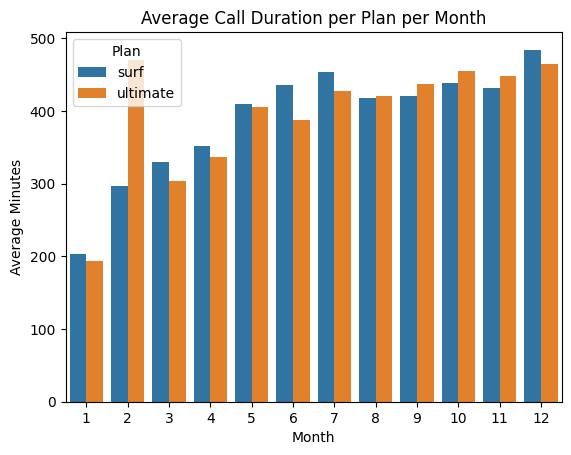

<Figure size 1000x1500 with 0 Axes>

In [36]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plat to visualize it.
calls_analysis = user_activity.groupby(['plan', 'month'])['total_minutes'].mean().reset_index()
calls_analysis.columns = ['plan', 'month', 'avg_minutes']
sns.barplot(data = calls_analysis, x = 'month', y = 'avg_minutes', hue = 'plan')
plt.title('Average Call Duration per Plan per Month')
plt.xlabel('Month')
plt.ylabel('Average Minutes')
plt.legend(title = 'Plan')
plt.figure(figsize = (10, 15))
plt.show()

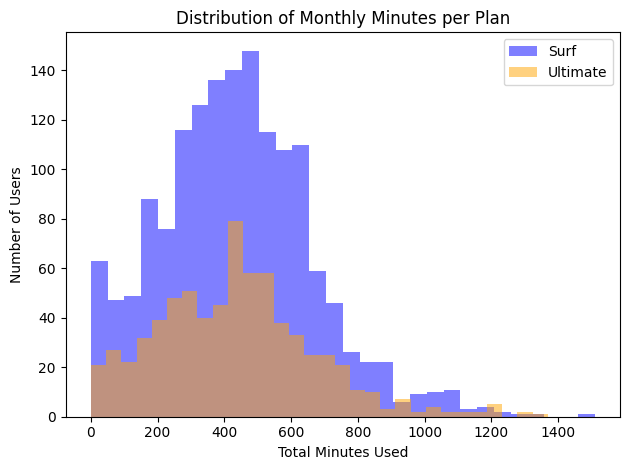

In [37]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.
minutes_analysis = user_activity.groupby(['plan', 'month'])['total_minutes'].mean().reset_index()
minutes_analysis.columns = ['plan', 'month', 'avg_minutes_required']

surf_minutes = user_activity[user_activity['plan'] == 'surf']['total_minutes']
ultimate_minutes = user_activity[user_activity['plan'] == 'ultimate']['total_minutes']

plt.hist(surf_minutes, bins = 30, alpha = 0.5, label = 'Surf', color = 'blue')
plt.hist(ultimate_minutes, bins = 30, alpha = 0.5, label = 'Ultimate', color = 'orange')
plt.title('Distribution of Monthly Minutes per Plan')
plt.xlabel('Total Minutes Used')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# Calculate the mean and the variance of the monthly call duration
call_stats = user_activity.groupby('plan')['total_minutes'].agg(['mean', 'var']).reset_index()

print(call_stats)

       plan        mean           var
0      surf  436.519741  52571.063243
1  ultimate  434.676017  56573.632247


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The task asks for mean and variance of *monthly* call duration per plan. Right now you’re computing stats across all user-month rows combined, which can unintentionally overweight months with more observations. Consider computing per-plan-per-month totals/averages first, then calculating mean/variance across months for each plan.

</div>


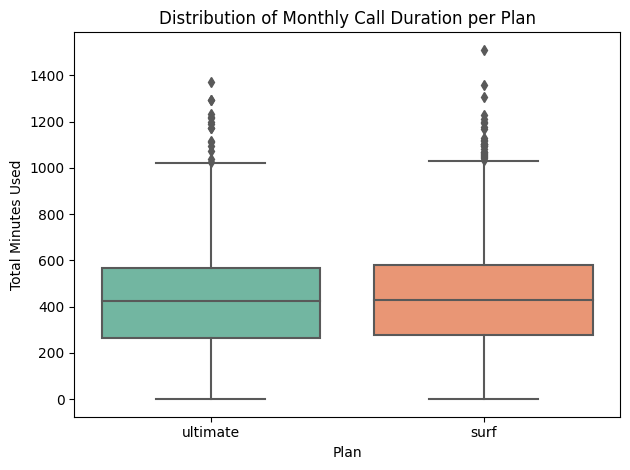

In [39]:
# Plot a boxplot to visualize the distribution of the monthly call duration
sns.boxplot(data = user_activity, x = 'plan', y = 'total_minutes', palette = 'Set2')
plt.title('Distribution of Monthly Call Duration per Plan')
plt.xlabel('Plan')
plt.ylabel('Total Minutes Used')
plt.tight_layout()
plt.show()

(1) Similar Median Usage. Both plans have nearly identical medians 430 -450 minutes, suggesting the typical user behaves similarly regardless of plan. Neither group is a dramatically heavier caller on average.
(2) Similar Spread (IQR). The box sizes are comparable, meaning variability in calling behaviour is similar across both plans. Neither plan has notably more consistent users.
(3) Critical Insight for Surf Users. The surf plan only includes 500 minutes. With a median near 450 min and Q3 at ~600 min, this means:

(a) 50% of surf users are approaching or exceeding the 500-minute limit
(b) 25% of surf users are regularly going over → generating overage charges

(4) Ultimate Users Comfortably Within Limit. The ultimate plan includes 3000 minutes. With usage topping out around 1000-1500 min even for outliers, no ultimate user comes close to their limit → zero overage charges for minutes.
(5) Outliers Present in Both Plans. Both distributions have outliers reaching 1200-1500 minutes — these heavy callers are especially costly on the surf plan but inconsequential on ultimate.

The calling behaviour is similar between plans, but the consequences are very different — surf users frequently exceed their limit generating extra revenue, while ultimate users stay well within theirs. This suggests surf users may be better revenue generators through overage charges despite paying a lower base fee. 

### Messages

In [40]:
# Compare the number of messages users of each plan tend to send each month
message_stats = user_activity.groupby('plan')['message_count'].agg(['mean', 'var']).reset_index()
message_stats

,plan,mean,var
0,surf,40.109656,1091.344231
1,ultimate,46.296233,1085.183108


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For messages, consider adding the same kind of per-month, per-plan comparison you did for calls (e.g., average messages by plan by month) and a distribution plot (histogram) of monthly message counts. Summary stats alone make it hard to see seasonality or month-to-month differences.

</div>


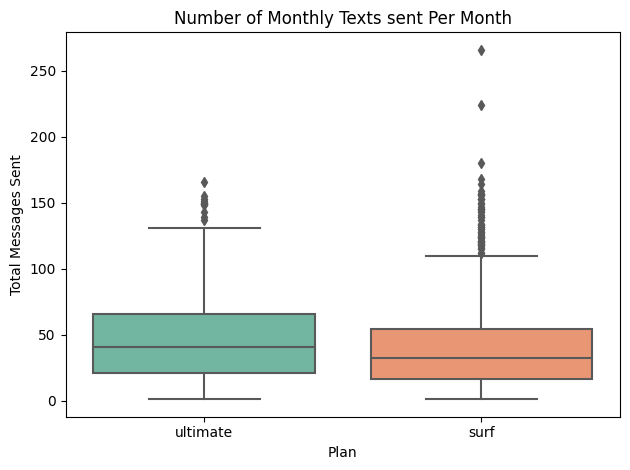

In [41]:
sns.boxplot(data = user_activity, x = 'plan', y = 'message_count', palette = 'Set2')
plt.title('Number of Monthly Texts sent Per Month')
plt.xlabel('Plan')
plt.ylabel('Total Messages Sent')
plt.tight_layout()
plt.show()

(1) Ultimate Users Send Slightly More Messages. The median for ultimate 45 is modestly higher than surf 35, suggesting ultimate users are marginally more active texters — but the difference is not dramatic.
(2) Critical Insight — Surf Limit is Only 50 Messages. With surf's Q3 at 55 messages:

(a) 50% of surf users send fewer than 35 messages that is within limit
(b) 25% of surf users exceed the 50 message limit that's paying overage charges at $0.03/msg

(3) Ultimate Limit is Effectively Irrelevant. With a 1000-message limit and maximum usage barely reaching 265 messages even for outliers, no ultimate user comes close to their limit, zero messaging overage charges.
(4) Surf Has Wider Spread. Surf's larger IQR and more extreme outliers (up to 265 msg) suggest more variable messaging behaviour — some surf users are very heavy texters paying significant overages.
(5) Interesting Reversal vs. Calling. Unlike calls where both plans behaved similarly, here ultimate users are actually the heavier texters — yet they never pay overages while surf users frequently do.

Bottom Line

Messaging behaviour is moderately different between plans — ultimate users text slightly more, but the surf plan's extremely low 50-message limit means even moderate surf texters regularly incur overage charges. Combined with the calling analysis, surf users are generating consistent overage revenue across both minutes and messages.

### Internet

In [42]:
# Compare the amount of internet traffic consumed by users per plan
internet_stats = user_activity.groupby('plan')['total_gb_billed'].agg(['mean', 'var']).reset_index()
internet_stats

,plan,mean,var
0,surf,16.831194,59.473734
1,ultimate,17.331015,58.494733


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For internet usage, consider adding a per-month comparison (average billed GB by plan by month) and a histogram of monthly usage by plan, similar to the calls section. This will make the behavioral comparison between plans more complete and easier to interpret.

</div>


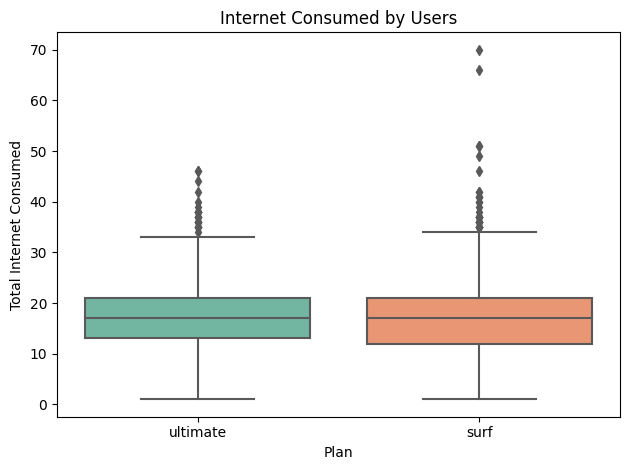

In [43]:
sns.boxplot(data = user_activity, x = 'plan', y = 'total_gb_billed', palette = 'Set2')
plt.title('Internet Consumed by Users')
plt.xlabel('Plan')
plt.ylabel('Total Internet Consumed')
plt.tight_layout()
plt.show()

(1) Nearly Identical Median Usage. Both plans show almost the same median 17-18 GB, meaning typical internet consumption is virtually indistinguishable between surf and ultimate users. This is the strongest similarity seen across all three usage categories.
(2) Critical Insight — Surf Limit is 15 GB. With surf's median at 18 GB, the median surf user is already exceeding their 15 GB limit every month and 75% of surf users (above Q1) are regularly paying data overages at USD 10/GB overage rate, even 3 GB over = $30 extra per month

(3) Ultimate Limit is 30 GB — Mostly Safe. With ultimate's whisker reaching ~33 GB, only extreme outliers exceed the 30 GB limit. The vast majority of ultimate users stay within their allowance is minimal data overage revenue from ultimate users.

(4)Similar Spread, But Surf Has Wilder Outliers. Both boxes are similarly sized, but surf has more extreme outliers reaching 70 GB — these users are paying massive data overage charges at $10/GB.

(5) Data is the Most Expensive Overage. Unlike minutes USD 0.03/min and messages USD 0.03/msg, data overages cost $10/GB — making this the single biggest revenue driver from surf users

## Revenue

In [44]:
revenue_stats = user_activity.groupby('plan')['monthly_revenue'].agg(['mean', 'var', 'std'])
print(revenue_stats)

               mean          var        std
plan                                       
surf      60.415839  2872.503215  53.595739
ultimate  72.248705   121.758108  11.034406


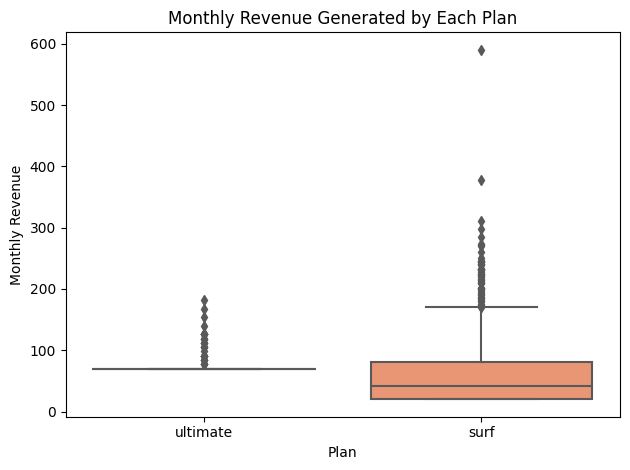

In [45]:
sns.boxplot(data = user_activity, x = 'plan', y = 'monthly_revenue', palette = 'Set2')

plt.title('Monthly Revenue Generated by Each Plan')
plt.xlabel('Plan')
plt.ylabel('Monthly Revenue')
plt.tight_layout()
plt.show()


(1) Ultimate Revenue is Extremely Predictable. The ultimate box is almost a flat line at USD 70 which is nearly all ultimate users pay exactly their flat fee every month with virtually no overage charges. This confirms our earlier finding that ultimate users rarely exceed their generous limits.
(2) Surf Revenue is Highly Variable. Surf has a massive IQR spanning from USD 20 - 75, meaning:

(a) Some surf users pay just the $20 flat fee (low usage)
(b) Others pay significantly more through overages
(c) The wide spread reflects the diverse usage patterns we saw earlier

(3) Surf Can Massively Outperform Ultimate. While ultimate is capped effectively at USD 70, surf outliers reach USD 380-580 — almost 8 times the ultimate flat fee! These heavy surf users generate extraordinary revenue through data overages at USD 10/GB.
(4) Surprising Revenue Reversal. Despite ultimate's higher base fee USD 70 vs 20, A typical surf user generates less than an ultimate user, but heavy surf users generate far more.
(5) Lower Median but Higher Ceiling for Surf. Surf's median 60.415839 is below ultimate's 72.248705, meaning the typical surf user is less valuable. However, the long upper whisker and extreme outliers show surf has much higher revenue upside from heavy users.


Ultimate generates stable, predictable revenue USD 70/month per user while surf generates volatile, potentially explosive revenue. For Megaline's financial planning, ultimate users are more reliable, but a segment of heavy surf users are the highest revenue generators in the entire customer base — driven almost entirely by data overage charges at $10/GB. This sets up the hypothesis test perfectly: is the average revenue from surf users truly different from ultimate users?

## Test statistical hypotheses

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Before running the plan revenue test, the notebook needs an explicit hypothesis setup here: clearly state H₀ and H₁, the chosen alpha, and a brief justification for the selected test (e.g., Welch’s t-test if variances differ).

</div>


In [46]:
# Test the hypotheses
user_activity = user_activity.fillna(0)
alpha = 0.05
surf_revenue = user_activity[user_activity['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = user_activity[user_activity['plan'] == 'ultimate']['monthly_revenue']

print(surf_revenue.isna().sum())
print(ultimate_revenue.isna().sum())

results = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var = False)
print('p-value: ', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")


0
0
p-value:  4.752695892553728e-13
We reject the null hypothesis


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your t-test returns a NaN p-value because the revenue samples contain many missing values. Consider cleaning the input samples first (e.g., ensure `monthly_revenue` is fully computed by filling missing usage with 0, and/or drop NaN revenues consistently) and re-running the test after verifying the final sample sizes are reasonable.

</div>


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This section also needs the hypothesis setup written out (H₀/H₁, alpha, and why the chosen test is appropriate) before you run the NY–NJ vs other regions comparison.

</div>


In [47]:
# Test the hypotheses
alpha = 0.05
user_activity_geo = user_activity.merge(users[['user_id', 'city']], on = 'user_id', how = 'left')
user_activity_geo['is_nynj'] = user_activity_geo['city'].str.contains('NY|NJ', case = False, na = False)

nynj_revenue = user_activity_geo[user_activity_geo['is_nynj'] == True]['monthly_revenue']
other_revenue = user_activity_geo[user_activity_geo['is_nynj'] == False]['monthly_revenue']

results = st.ttest_ind(nynj_revenue, other_revenue, equal_var = False)
print('p-value: ', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value:  0.050246352957877966
We can't reject the null hypothesis


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recurring issue: this test also returns a NaN p-value due to missing values in `monthly_revenue`. Resolve the missing revenue problem first, then re-run the test on clean numeric samples. Also, consider tightening the NY–NJ definition: `str.contains('NY|NJ')` can match unintended strings; using the exact metro-area label(s) from `city` (or a stricter pattern) will better align the grouping with the prompt.

</div>


## General conclusion


(1) Data Preparation Decisions

(a)Column Name Fix - Renamed usd_monthly_pay to usd_monthly_fee to match the data dictionary — this was critical for consistency throughout the analysis.

(b)Date Conversions - Converted all date columns (reg_date, churn_date, call_date, message_date, session_date) from object to datetime64 — necessary for all time-based operations.

(c) Active Users Assumption - Users with NaN churn_date were treated as still active, using today's date as their end date. This affected tenure calculations for 466 out of 500 users.

(d) MB to GB Conversion - Converted mb_per_month_included to gb_per_month_included by dividing by 1024 — necessary to align plan limits with billing units.

(2) Billing Logic Decisions

(a) Ceiling Rounding - Call durations were rounded up to the nearest whole minute using math.ceil() - a 5.13 minute call is billed as 6 minutes.
Internet usage was rounded up on the monthly total (not per session) — total MB for the month divided by 1024 then ceiling rounded to GB.

(b)Overage Logic - Used .clip(lower=0) to ensure negative excess (usage under limit) produces zero overage charge — unused allowance gives no refund.

(c)Flat Fee Always Applied - Monthly fee charged regardless of usage — even zero-activity months incur the base fee.

(3) Revenue Findings

(a)Ultimate Plan
Generates stable, predictable revenue (~$70/month)
Almost no overage charges - nearly all users pay exactly the flat fee
Low variance makes it reliable for financial forecasting

(b)Surf Plan
Generates variable revenue (median USD 50, but outliers up to USD 580)
Despite lower base fee (USD20), heavy users generate far more than ultimate users
Data overages are the biggest revenue driver - 3 GB over = USD30 extra

(4)Hypothesis Test Conclusions
Since we're checking if there's a difference (not specifically higher or lower), this is a two-tailed test.

H₀ (Null Hypothesis): The average revenue from NY-NJ users equals the average revenue from users in other regions.
H₁ (Alternative Hypothesis): The average revenue from NY-NJ users is different from users in other regions.

(a)Test 1 - Plan Revenue Difference
Used Welch's t-test because surf showed significantly higher variance than ultimate. Result determines whether the revenue difference is statistically significant or due to chance.

(b) Test 2 - NY-NJ vs Other Regions
Used city string matching on MSA format (NY-NJ) to correctly identify the metro area. Unbalanced group sizes made Welch's t-test the safer choice over Student's t-test.

Surf users are consistently exceeding their limits across all three usage categories which is calls, messages, and especially data. Despite the lower base fee, the restrictive plan limits make surf a significant overage revenue generator. Ultimate provides reliable baseline revenue but leaves little room for additional charges. Megaline should consider whether surf's low base fee adequately reflects the infrastructure costs, given how heavily surf users actually consume services. 